# Phase 2 — Data-Quality Report & Exploratory Data Analysis
This notebook performs a comprehensive data-quality analysis of the training and test sets for the **ForgeMind APS** project.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Loading
We load both the training and testing datasets. Missing values in the raw files are encoded as the string `"na"`, which we must convert to actual `NaN` values on load.

In [2]:
data_dir = os.path.join("..", "dataset")
train_path = os.path.join(data_dir, "aps_failure_training_set.csv")
test_path = os.path.join(data_dir, "aps_failure_test_set.csv")

print("Loading training data...")
train_df = pd.read_csv(train_path, na_values=["na"])
print("Loading test data...")
test_df = pd.read_csv(test_path, na_values=["na"])

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading training data...
Loading test data...
Train shape: (60000, 171)
Test shape: (16000, 171)


## 2. Target Class Balance
Let's look at the class distribution in training and test sets to understand the level of class imbalance.

In [3]:
print("Train class distribution:")
print(train_df['class'].value_counts())
print(f"Train positive class ratio: {train_df['class'].value_counts(normalize=True)['pos'] * 100:.3f}%")

print("\nTest class distribution:")
print(test_df['class'].value_counts())
print(f"Test positive class ratio: {test_df['class'].value_counts(normalize=True)['pos'] * 100:.3f}%")

Train class distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64
Train positive class ratio: 1.667%

Test class distribution:
class
neg    15625
pos      375
Name: count, dtype: int64
Test positive class ratio: 2.344%


## 3. Missingness Analysis
Next, we investigate the structure and magnitude of missing values.

In [4]:
train_missing = train_df.isnull().sum()
train_missing_pct = (train_missing / len(train_df)) * 100

test_missing = test_df.isnull().sum()
test_missing_pct = (test_missing / len(test_df)) * 100

missing_stats = pd.DataFrame({
    'train_missing_count': train_missing,
    'train_missing_pct': train_missing_pct,
    'test_missing_count': test_missing,
    'test_missing_pct': test_missing_pct
}).drop(index='class')

print(f"Total features with at least one missing value in train: {len(missing_stats[missing_stats['train_missing_count'] > 0])} / 170")
print(f"Features with > 50% missing values: {len(missing_stats[missing_stats['train_missing_pct'] > 50])}")
print(missing_stats[missing_stats['train_missing_pct'] > 50])

Total features with at least one missing value in train: 169 / 170
Features with > 50% missing values: 8
        train_missing_count  train_missing_pct  test_missing_count  \
ab_000                46329          77.215000               12363   
bm_000                39549          65.915000               10546   
bn_000                44009          73.348333               11713   
bo_000                46333          77.221667               12376   
bp_000                47740          79.566667               12721   
bq_000                48722          81.203333               12981   
br_000                49264          82.106667               13129   
cr_000                46329          77.215000               12363   

        test_missing_pct  
ab_000          77.26875  
bm_000          65.91250  
bn_000          73.20625  
bo_000          77.35000  
bp_000          79.50625  
bq_000          81.13125  
br_000          82.05625  
cr_000          77.26875  


Let's look at the distribution of missingness across rows.

Row-wise missing values distribution in Train:
count    60000.000000
mean        14.166917
std         16.095888
min          0.000000
25%          8.000000
50%          8.000000
75%         16.000000
max        168.000000
dtype: float64


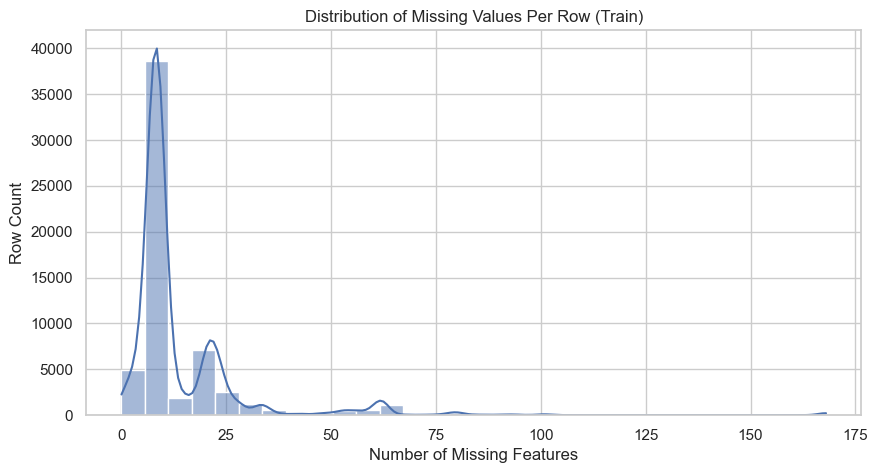

In [5]:
row_missing_train = train_df.drop(columns=['class']).isnull().sum(axis=1)
print("Row-wise missing values distribution in Train:")
print(row_missing_train.describe())

plt.figure(figsize=(10, 5))
sns.histplot(row_missing_train, bins=30, kde=True)
plt.title('Distribution of Missing Values Per Row (Train)')
plt.xlabel('Number of Missing Features')
plt.ylabel('Row Count')
plt.show()

## 4. Constant Features
Let's check if any column has zero variance (the same value for all rows) in the training set, and verify if it is also constant in the test set.

In [6]:
train_numeric = train_df.drop(columns=['class'])
constant_cols = [col for col in train_numeric.columns if train_numeric[col].nunique(dropna=True) <= 1]
print(f"Constant columns in train: {constant_cols}")

for col in constant_cols:
    print(f"{col} unique values in train: {train_df[col].unique()}")
    print(f"{col} unique values in test: {test_df[col].unique()}")

Constant columns in train: ['cd_000']
cd_000 unique values in train: [1209600.      nan]
cd_000 unique values in test: [1209600.      nan]


## 5. Feature Distributions & Scale
Let's analyze the scale and skewness of the numeric predictors.

In [7]:
skewness = train_numeric.skew()
print(f"Features with absolute skewness > 10: {len(skewness[abs(skewness) > 10])} / 170")
print(f"Maximum skewness: {skewness.max():.2f}")
print("\nTop 10 most skewed features:")
print(skewness.sort_values(ascending=False).head(10))

Features with absolute skewness > 10: 114 / 170
Maximum skewness: 243.53

Top 10 most skewed features:
cs_009    243.531177
cf_000    212.459407
co_000    212.459406
ad_000    212.459406
dh_000    202.907014
az_009    163.609146
ay_009    159.066837
ag_000    153.387555
dj_000    150.507647
cs_007    140.732294
dtype: float64


Let's also look at the massive differences in scale across features. We compute the range of each feature.

Distribution of Feature Ranges:
count    1.700000e+02
mean     2.596654e+08
std      1.235150e+09
min      0.000000e+00
25%      1.310700e+06
50%      2.230067e+07
75%      7.719656e+07
max      8.584298e+09
dtype: float64


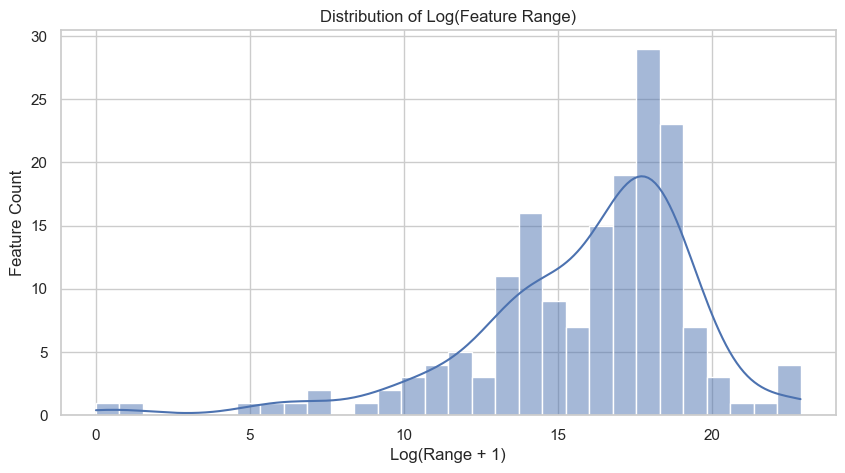

In [8]:
ranges = train_numeric.max() - train_numeric.min()
print("Distribution of Feature Ranges:")
print(ranges.describe())

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(ranges), bins=30, kde=True)
plt.title('Distribution of Log(Feature Range)')
plt.xlabel('Log(Range + 1)')
plt.ylabel('Feature Count')
plt.show()

## 6. Correlation Structure
Let's analyze multicollinearity and check for extreme correlations. To speed up calculation, we fill missing values with their medians first, avoiding slow pairwise NaN deletion.

In [9]:
train_filled = train_numeric.fillna(train_numeric.median())
corr_matrix = train_filled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
extremely_corr = [(column, row, upper_tri.loc[row, column]) 
                  for column in upper_tri.columns 
                  for row in upper_tri.index 
                  if upper_tri.loc[row, column] >= 0.95]

print(f"Pairs with Pearson correlation >= 0.95: {len(extremely_corr)}")
print("\nExtremely correlated pairs (>= 0.99):")
for col1, col2, val in sorted(extremely_corr, key=lambda x: x[2], reverse=True):
    if val >= 0.99:
        print(f"{col1} <-> {col2}: {val:.6f}")

Pairs with Pearson correlation >= 0.95: 55

Extremely correlated pairs (>= 0.99):
cq_000 <-> bv_000: 1.000000
cq_000 <-> bu_000: 1.000000
bv_000 <-> bu_000: 1.000000
co_000 <-> cf_000: 1.000000
cf_000 <-> ad_000: 1.000000
co_000 <-> ad_000: 1.000000
bt_000 <-> aa_000: 0.998774
bg_000 <-> ah_000: 0.997745
bv_000 <-> bb_000: 0.996258
bu_000 <-> bb_000: 0.996258
cq_000 <-> bb_000: 0.996258
cc_000 <-> bx_000: 0.996180


## 7. Conclusions & Handling Plan
1. **Constant Feature**: `cd_000` has std dev 0.0 in both train and test. It provides no information and will be dropped.
2. **Missing values**: Imputation is necessary. For baseline/simple models, we will use median imputation since the distributions are highly skewed. We will also evaluate keeping/adding missing value indicator columns for features with high missingness.
3. **Scaling & Skewness**: Due to extreme skewness and range variation, power/log transforms or RobustScaler/QuantileTransformer should be considered for models sensitive to scale (such as SVMs).